In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Radii of the ellipsoid
# s = [1, 0.5, 0.01] # disc
s = [0.25, 0.05, 0.01]
sx, sy, sz  = s
v1 = np.array([sx, 0, 0])
v2 = -np.array([0, sy, 0])
v3 = np.array([0, 0, sz])
vectors = np.array([v1, v2, v3]).T  # shape (3, N)
s_min, s_mid, s_max = np.sort(s)
curv = s_min**2/(s_min**2 + s_mid**2 + s_max**2)

# Create parameterization
u = np.linspace(0, 2 * np.pi, 20)
v = np.linspace(0, np.pi, 20)
u, v = np.meshgrid(u, v)

# Parametric equations for the ellipsoid
x = sx * np.cos(u) * np.sin(v)
y = sy * np.sin(u) * np.sin(v)
z = sz * np.cos(v)

# Plot the surface
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, color='lightblue', edgecolor="black", alpha=0.3, linewidth=0.1)

# Axes settings
ax.set_xlim(-sx, sx)
ax.set_ylim(-sx, sx)
ax.set_zlim(-sx, sx)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'[min/mid, min/max, mid/max] = [{s_min/s_mid:.3f}, {s_min/s_max:.3f}, {s_mid/s_max:.3f}]')

# Equal aspect ratio for better visual
ax.set_box_aspect([sx, sx, sx])  # match axis scales to ellipsoid shape
ax.quiver(*np.array([0,0,0]).T, *vectors, color=['r', 'g', 'b'], length=1.0, normalize=False)
plt.tight_layout()
plt.show()


[[100, 9.99], [9.99, 1]]
Eigenvalues: [1.00998021e+02 1.97924671e-03]
Eigenvalues (manual): [1.00998021e+02 1.97924671e-03]
Curvature: 1.959650205053607e-05
Eigenvectors:
 [[-0.99504684  0.09940715]
 [-0.09940715 -0.99504684]]


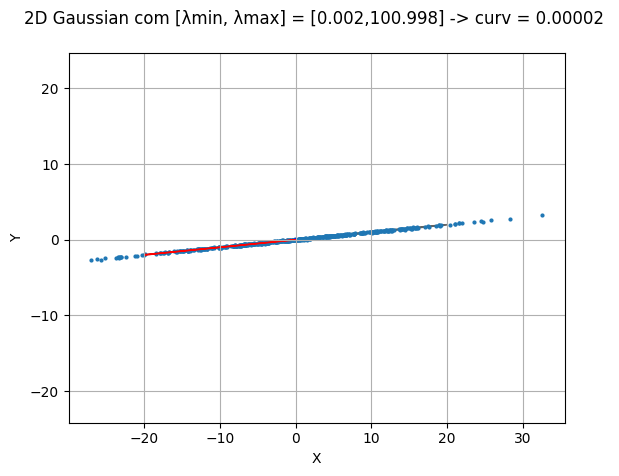

In [194]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Example data
mean = [0, 0]
b = 9.99
cov_matrix = [[100, b], [b, 1]]
print(cov_matrix)
data = np.random.multivariate_normal(mean, cov_matrix, size=500)

def get_curvature(eigvals):
    s_max, s_min = eigvals
    curvature = s_min / (s_min + s_max)
    return curvature

def get_eigen(cov):
    a, b, c = cov[0][0], cov[0][1], cov[1][1]
    term = np.sqrt((a - c)**2 + 4*b**2)
    eig1 = (a + c + term) / 2
    eig2 = (a + c - term) / 2
    return np.array([eig1, eig2])

# Function to plot confidence ellipse
def plot_confidence_ellipse(cov, mean, ax, n_std=2.0, **kwargs):
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]
    print("Eigenvalues:", eigvals)
    print("Eigenvalues (manual):", get_eigen(cov))

    curv = get_curvature(eigvals)
    print("Curvature:", curv)
    print("Eigenvectors:\n", eigvecs)

    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))
    width, height = 2 * n_std * np.sqrt(eigvals)
    ellipse = Ellipse(xy=mean, width=width, height=height, angle=angle, **kwargs)
    ax.add_patch(ellipse)
    return eigvals, curv ,eigvecs

# Plot data and ellipse
fig, ax = plt.subplots()
eigvals, curv, eigvecs = plot_confidence_ellipse(cov_matrix, mean, ax, edgecolor='k', facecolor='lightblue', alpha=0.6, label='Confidence Ellipse')
ax.scatter(data[:, 0], data[:, 1], s=4, label='Data points')

s_max, s_min = eigvals
# ax.axvline(0, color='black', linestyle='--', linewidth=0.8)
# ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax.arrow(0,0,  eigvecs[0,1]*2 * np.sqrt(s_min), eigvecs[1,1]*2 * np.sqrt(s_min), color='blue', width=0.05, label='v_0 (min)', length_includes_head=True)
ax.arrow(0,0,  eigvecs[0,0]*2 * np.sqrt(s_max), eigvecs[1,0]*2 * np.sqrt(s_max), color='red', width=0.05, label='v_1 (max)', length_includes_head=True)

# ax.legend()

ax.set_aspect("equal", adjustable='datalim')  # match axis scales to ellipsoid shape
# l = 4.5
# ax.set_ylim(-l, l)
# ax.set_xlim(-l, l)
plt.title(f'2D Gaussian com [λmin, λmax] = [{s_min:.3f},{s_max:.3f}] -> curv = {curv:.5f} \n')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.show()

2.0